In [1]:
# https://drive.google.com/file/d/1uzPu1G33O3yG3wQRSRZLVIHIIjtZ1X5h/view?usp=drive_link

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting, let's verify the contents of your 'My Drive' to locate the 'Colab Notes' folder and your CSV file. Run the next cell to list the contents.

In [3]:
# This command lists all files and folders directly in 'My Drive'
# Use this to find the correct path for your CSV file.
!ls '/content/drive/My Drive/'

'01. Reference Check Bell (Brown)- pending.gdoc'
'01. Reference Check Bell (Brown)- pending.pdf'
 5.jpg
 6.jpg
 appsheet
'Client File Cover Sheet - Copy.docx'
'Closing Contact Info for All Parties.docx'
'Cocktail Recipes Database.gsheet'
'Colab Notebooks'
'Copy of Project Management Q&A Guide.docx'
'Dave and Alicia Vehicle Maintenance Schedule.xlsx'
'DISCLOSURES PART 1 of 2.pdf'
'Gemini Gems'
 GSCCCA05082024.pdf
'Honors Request Form_Fillable.pdf'
 MGMT7000
 MKTG7000
'sample model card.gsheet'


Once you've confirmed the 'Colab Notes' folder is visible and you have the correct path, run the next cell to read your CSV file. I've updated the path based on our previous conversation.

In [4]:
import pandas as pd

# The corrected path now uses 'Colab Notebooks' as seen in the 'ls' output.
csv_file_path = '/content/drive/My Drive/Colab Notebooks/Pakistan Largest Ecommerce Dataset.csv'

try:
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded CSV from: {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path and make sure your Drive is mounted correctly.")
except Exception as e:
    print(f"An error occurred: {e}")

/tmp/ipykernel_3595/1929024856.py:7: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


Successfully loaded CSV from: /content/drive/My Drive/Colab Notebooks/Pakistan Largest Ecommerce Dataset.csv


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [5]:
cancellation_statuses = ['canceled']
non_cancellation_statuses = ['complete', 'received']

In [6]:
df = df[df['status'].isin(cancellation_statuses + non_cancellation_statuses)].copy()
df['is_canceled'] = df['status'].apply(lambda x: 1 if x == 'canceled' else 0)

In [7]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['day_of_week'] = df['created_at'].dt.dayofweek
df['hour'] = df['created_at'].dt.hour  # If time is available

In [8]:
df['discount_ratio'] = df['discount_amount'] / (df['grand_total'] + 1e-5)
df['is_cod'] = (df['payment_method'] == 'cod').astype(int)
df['has_discount'] = (df['discount_amount'] > 0).astype(int)

In [35]:
import numpy as np

df = df.sort_values('created_at')
df['prev_orders'] = df.groupby('Customer ID').cumcount()
df['prev_cancellations'] = df.groupby('Customer ID')['is_canceled'].cumsum() - df['is_canceled']
df['customer_cancel_rate'] = np.where(
    df['prev_orders'] > 0,
    df['prev_cancellations'] / df['prev_orders'],
    0
)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import lightgbm as lgb

In [14]:
features = [
    'price', 'qty_ordered', 'grand_total', 'discount_amount',
    'discount_ratio', 'is_cod', 'has_discount',
    'day_of_week', 'customer_cancel_rate', 'category_name_1', 'payment_method'
]

X = df[features]
y = df['is_canceled']

In [15]:
for col in ['category_name_1', 'payment_method']:
    X[col] = X[col].astype('category')

/tmp/ipykernel_3595/4169563755.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_3595/4169563755.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')


In [16]:
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [17]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

In [18]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 149477, number of negative: 260302
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 409779, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.364775 -> initscore=-0.554700
[LightGBM] [Info] Start training from score -0.554700


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42,
               scale_pos_weight=1.7414184121971943)

In [19]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")

ROC-AUC Score: 0.8560
PR-AUC (Average Precision): 0.8445


In [20]:
import shap
import matplotlib.pyplot as plt

In [21]:
import lightgbm as lgb

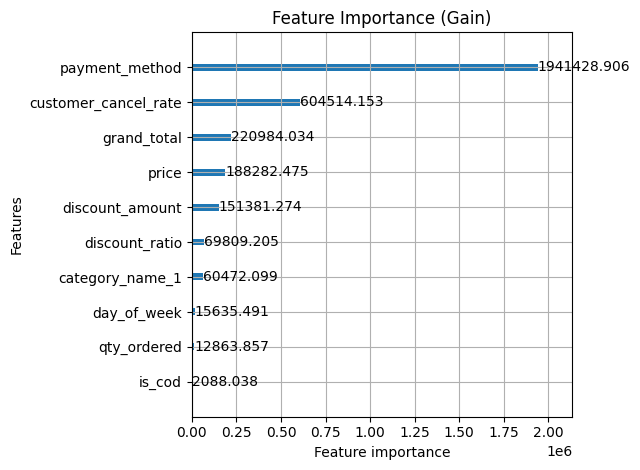

In [22]:
lgb.plot_importance(model, max_num_features=10, importance_type='gain', title='Feature Importance (Gain)')
plt.tight_layout()
plt.show()

### SHAP Value Visualization

SHAP (SHapley Additive exPlanations) values help explain the output of any machine learning model. For tree-based models like LightGBM, `shap.TreeExplainer` is an efficient way to calculate these values. We'll visualize the SHAP summary plot to see how each feature contributes to the model's prediction.

In [30]:
# Initialize JS for SHAP plots (if not already initialized)
shap.initjs()

# Create a SHAP explainer object for the LightGBM model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for a subset of the test data for faster computation
# Using a small sample of X_test for demonstration
X_test_sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## LightGBM Model Loading and Training

This section demonstrates the process of preparing data and training a LightGBM classification model to predict cancellations.

### 1. Define Features and Target Variable

First, we define the list of features (`X`) that will be used for training the model and the target variable (`y`), which indicates whether an order was canceled.

In [25]:
features = [
    'price', 'qty_ordered', 'grand_total', 'discount_amount',
    'discount_ratio', 'is_cod', 'has_discount',
    'day_of_week', 'customer_cancel_rate', 'category_name_1', 'payment_method'
]

X = df[features]
y = df['is_canceled']

print("Features selected:", features)
print("Target variable: 'is_canceled'")

Features selected: ['price', 'qty_ordered', 'grand_total', 'discount_amount', 'discount_ratio', 'is_cod', 'has_discount', 'day_of_week', 'customer_cancel_rate', 'category_name_1', 'payment_method']
Target variable: 'is_canceled'


### 2. Convert Categorical Features

LightGBM can handle categorical features directly if they are cast to the 'category' data type. This step converts the relevant columns.

In [26]:
for col in ['category_name_1', 'payment_method']:
    X[col] = X[col].astype('category')

print("Categorical features converted.")

Categorical features converted.


/tmp/ipykernel_3595/3790631205.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_3595/3790631205.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')


### 3. Split Data into Training and Testing Sets

We split the dataset into training and testing sets based on a time-based split (80% for training, 20% for testing) to simulate a real-world scenario where the model predicts future cancellations.

In [27]:
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 409779 samples
Testing set size: 102445 samples


### 4. Calculate `scale_pos_weight`

Since cancellation events are often imbalanced (fewer cancellations than non-cancellations), we calculate `scale_pos_weight` to help the model handle this imbalance by giving more importance to the positive class (cancellations) during training.

In [28]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Calculated scale_pos_weight: 1.74


### 5. Train the LightGBM Model

Finally, we define and train the `LGBMClassifier` using the prepared training data. `n_estimators` is set to 300, `learning_rate` to 0.05, and `scale_pos_weight` is applied to address class imbalance.

In [29]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

print("LightGBM model training complete.")

[LightGBM] [Info] Number of positive: 149477, number of negative: 260302
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 409779, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.364775 -> initscore=-0.554700
[LightGBM] [Info] Start training from score -0.554700
LightGBM model training complete.


In [31]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.2 MB/s eta 0:00:00


In [32]:
import optuna
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

In [37]:
def objective(trial):
    # Search space definition
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )

        preds = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, preds)
        pr_auc_scores.append(score)

    return np.mean(pr_auc_scores)

In [40]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5, timeout=300)

print(f"Best PR-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")

[I 2026-09-27 20:50:56,568] A new study created in memory with name: no-name-1bfe4b23-7c16-40e0-b11a-0f61c43679de
[I 2026-09-27 20:53:10,900] Trial 0 finished with value: 0.8470969614829013 and parameters: {'n_estimators': 448, 'learning_rate': 0.11784620619221893, 'num_leaves': 75, 'max_depth': 4, 'min_child_samples': 29, 'subsample': 0.5007088120521721, 'colsample_bytree': 0.8769067786550682, 'scale_pos_weight': 5.771541116523029, 'reg_alpha': 0.19186645516024653, 'reg_lambda': 0.00021847303208906993}. Best is trial 0 with value: 0.8470969614829013.
[I 2026-09-27 20:55:44,415] Trial 1 finished with value: 0.8407517946467241 and parameters: {'n_estimators': 346, 'learning_rate': 0.019184737423638146, 'num_leaves': 62, 'max_depth': 6, 'min_child_samples': 41, 'subsample': 0.9444858845417661, 'colsample_bytree': 0.8335344265123856, 'scale_pos_weight': 7.360276233342597, 'reg_alpha': 0.00399334815371015, 'reg_lambda': 3.176035439736355e-07}. Best is trial 0 with value: 0.8470969614829013

Best PR-AUC Score: 0.8471
Best Hyperparameters:
  'n_estimators': 448
  'learning_rate': 0.11784620619221893
  'num_leaves': 75
  'max_depth': 4
  'min_child_samples': 29
  'subsample': 0.5007088120521721
  'colsample_bytree': 0.8769067786550682
  'scale_pos_weight': 5.771541116523029
  'reg_alpha': 0.19186645516024653
  'reg_lambda': 0.00021847303208906993


In [41]:
best_params = study.best_params
final_model = lgb.LGBMClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8769067786550682,
               learning_rate=0.11784620619221893, max_depth=4,
               min_child_samples=29, n_estimators=448, num_leaves=75,
               random_state=42, reg_alpha=0.19186645516024653,
               reg_lambda=0.00021847303208906993,
               scale_pos_weight=5.771541116523029,
               subsample=0.5007088120521721)

In [42]:
y_probs = final_model.predict_proba(X_test)[:, 1]

In [43]:
thresholds = np.linspace(0.01, 0.99, 100)
best_threshold = 0.5
best_f1 = 0

In [44]:
from sklearn.metrics import f1_score

for t in thresholds:
    y_pred_binary = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_binary)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal Probability Threshold: {best_threshold:.2f}")
print(f"Optimal F1-Score: {best_f1:.4f}")

Optimal Probability Threshold: 0.77
Optimal F1-Score: 0.7892
